# Filtering
## Simple First-order Case First

In [5]:
%reload_ext autoreload
%autoreload 2

In [6]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()

import control_materials as cm
print("Control Material version:", cm.__version__)
cm.setup_environment()


Basic Material version: 16.002-0.1
Control Material version: 16.002-0.1


In [7]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [8]:
f_d = 1/2/np.pi #             % input freq Hz
t = np.linspace(0,30,1000) #            % simulation time
omega = np.logspace(-2,2,1000) #   % frequency 
# define P as a transfer function
P = ct.tf([1],[1, 1])
cm.show_tf_latex(P, "P(s)")

<IPython.core.display.Math object>

/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


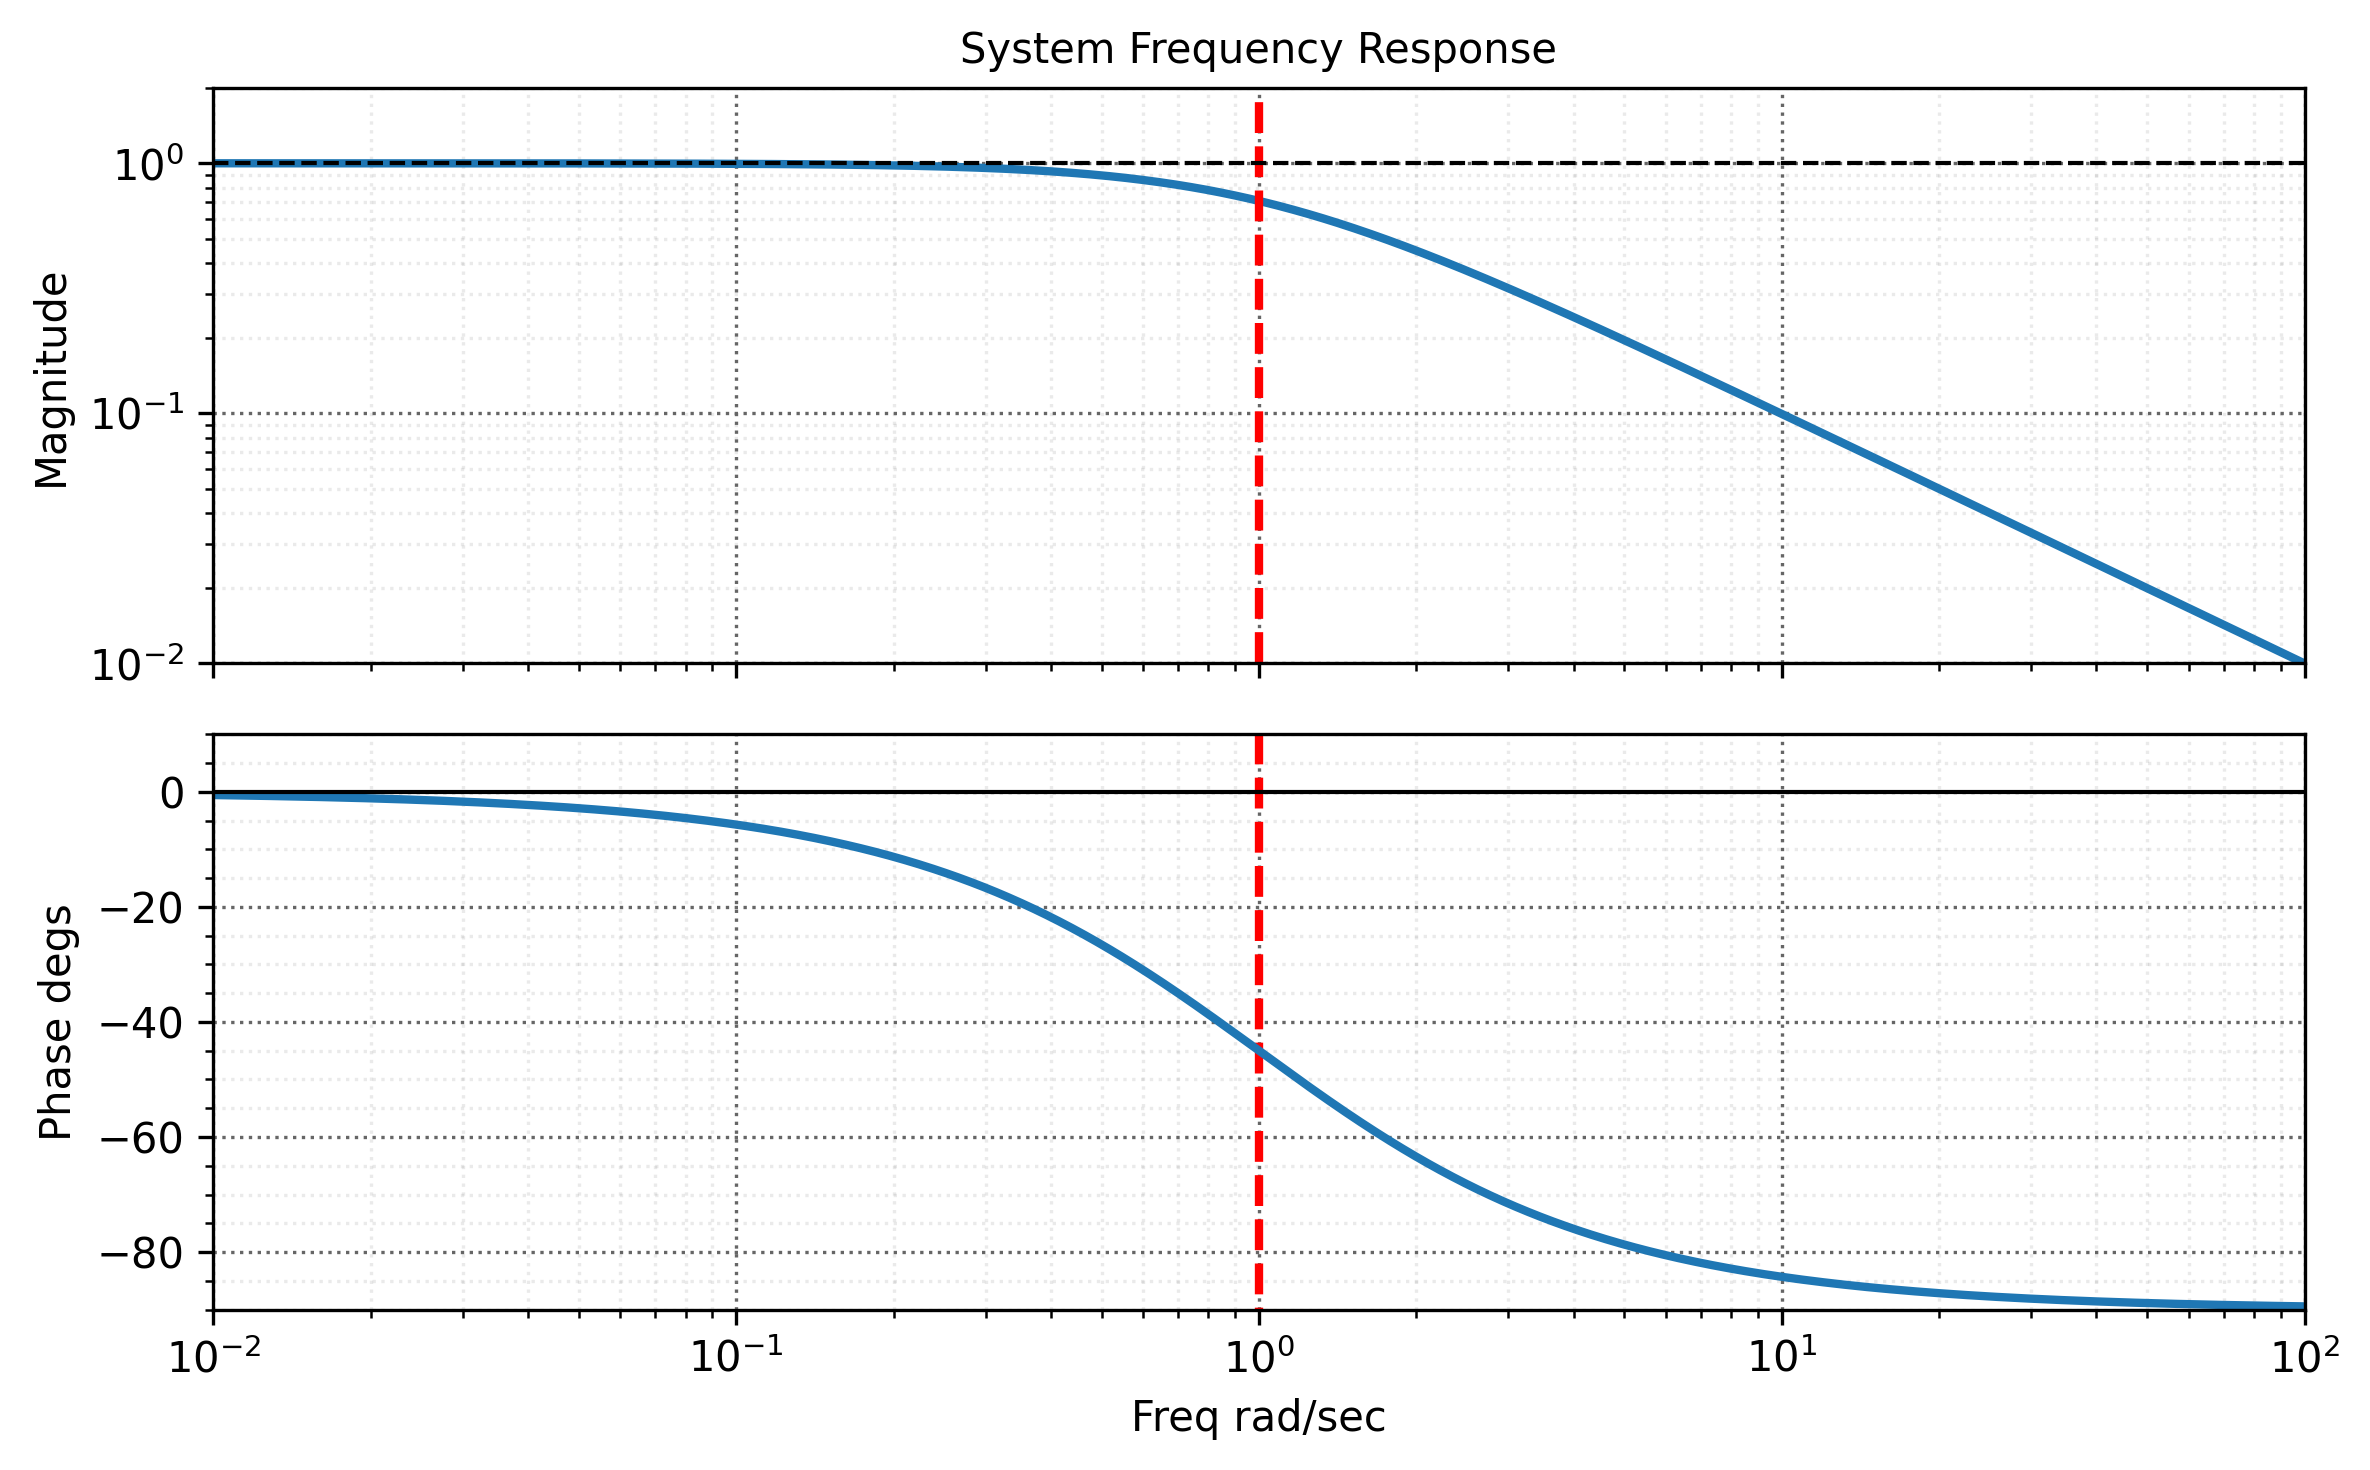

In [9]:
gain, phase, w = ct.bode(P, omega,plot=False)
fig, (ax1, ax2) = plt.subplots(2,figsize=(8,5), dpi=300, sharex = True)
ax1.set_title('System Frequency Response')
ax1.loglog(w, gain)
ax1.vlines(f_d*2*np.pi,.01,2,colors='r',ls='dashed')
ax2.vlines(f_d*2*np.pi,-190,10,colors='r',ls='dashed')
ax2.semilogx(w, phase*cm.r2d)
ax2.set_xlabel('Freq rad/sec')
ax2.set_ylabel('Phase degs')
ax1.set_ylabel('Magnitude')
bm.nicegrid(ax1)
bm.nicegrid(ax2)
ax1.set_ylim([.01,2])
ax2.set_ylim([-90,10])
fig.savefig('./figs/T7_e22_1.pdf',  format='pdf', dpi=300)
plt.show()

In [10]:
# for plotting
II = np.argwhere(np.abs(omega-f_d*2*np.pi) < 1e-2)[0]
Shift_values = [abs(gain[II]), phase[II]]            # ampl and phase shift      

In [11]:
w = np.sin(f_d*2*np.pi*t);                            # input
wshift = Shift_values[0]*np.sin(f_d*2*np.pi*t + Shift_values[1]);   # shifted input
y,t,xout = cmat.lsim(P,w,t,0)                  # simulated output

/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/control/timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


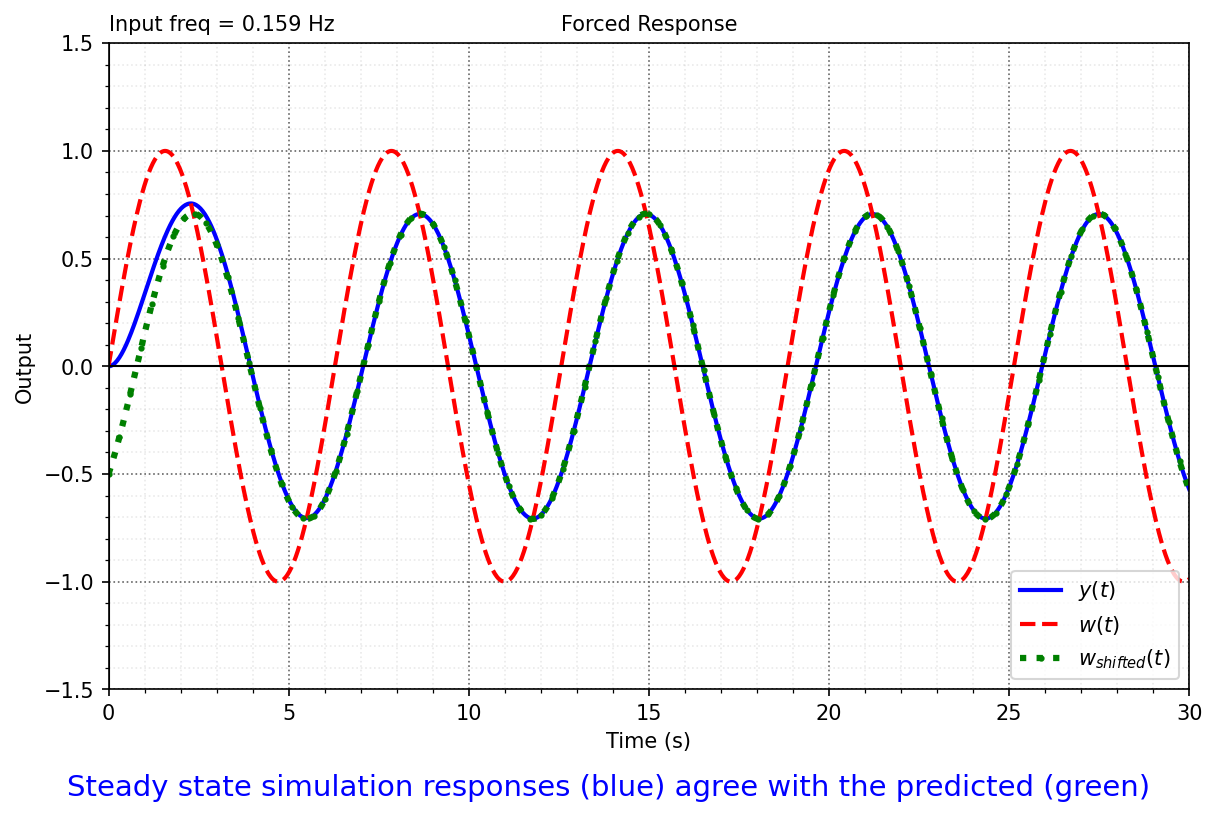

In [12]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t,y,'b-',label='$y(t)$')
plt.plot(t,w,'r--',label='$w(t)$')
plt.plot(t,wshift,'go:',label='$w_{shifted}(t)$',lw=3,ms=2,markevery=10)
bm.nicegrid()
plt.legend()
plt.xlim(0,max(t))
plt.ylim(-1.5,1.5)
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.title('Forced Response')
plt.title('Input freq = '+str(np.round(f_d,3))+' Hz',loc='left')
cm.caption("Steady state simulation responses (blue) agree with the predicted (green)",fig)
fig.savefig('./figs/T7_e22_2.pdf', format='pdf', dpi=300)
plt.show()

# Section 7.16 - Second Order System

In [13]:
M = 1
K = 2
B = 0.1
f_d = 1.5/2/np.pi #             % input freq Hz
omega = np.logspace(-1,1,10000) #   % frequency 

In [14]:
# define P as a transfer function
P = ct.tf([0, 1],[M, B, K])
Pf = P(1j*omega)
gain = np.abs(Pf)
phase = np.angle(Pf)

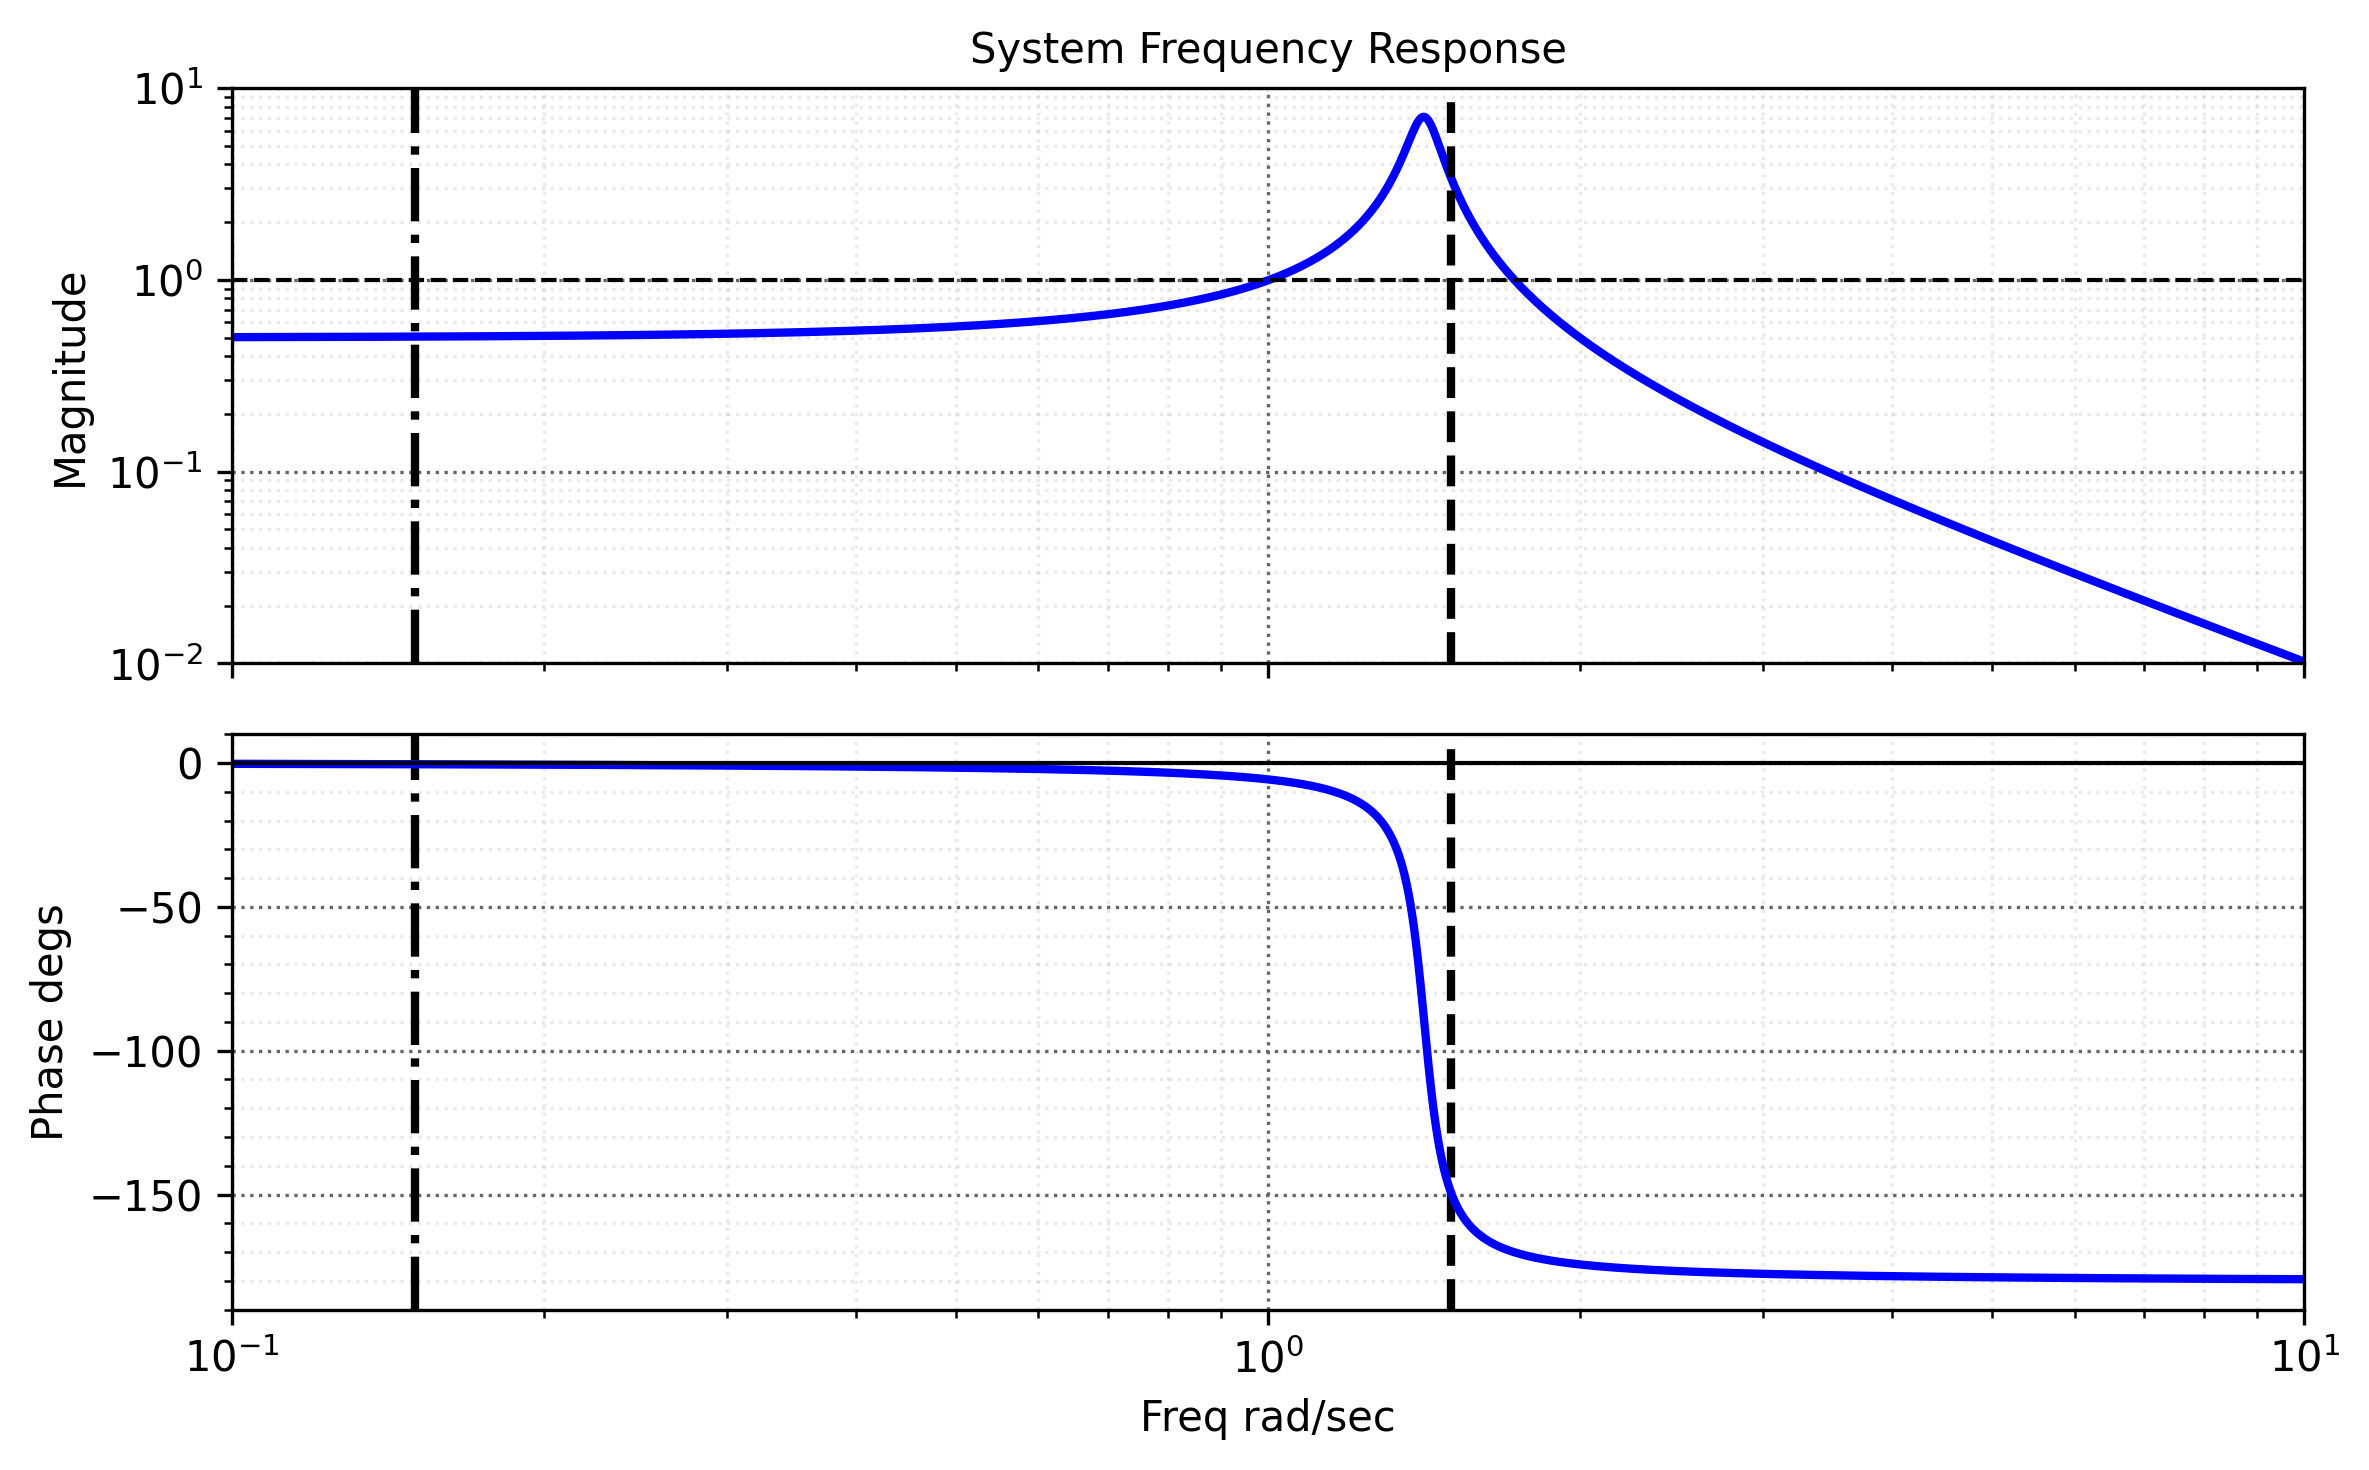

In [15]:
fig, (ax1, ax2) = plt.subplots(2,figsize=(8,5), dpi=300, sharex = True)
ax1.set_title('System Frequency Response')
ax1.loglog(omega, gain,'b')
ax1.vlines(f_d*2*np.pi,.01,10,colors='k',ls='--')
ax2.vlines(f_d*2*np.pi,-190,10,colors='k',ls='--')
ax1.vlines(f_d*2*np.pi/10,.01,10,colors='k',ls='-.')
ax2.vlines(f_d*2*np.pi/10,-190,10,colors='k',ls='-.')
ax2.semilogx(omega, phase*cm.r2d,'b')
ax2.set_xlabel('Freq rad/sec')
ax2.set_ylabel('Phase degs')
ax1.set_ylabel('Magnitude')
bm.nicegrid(ax1)
bm.nicegrid(ax2)
ax1.set_ylim([.01,10])
ax2.set_ylim([-190,10])
fig.savefig('./figs/T7_s17_1.pdf',  format='pdf', dpi=300)
plt.show()

/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/control/timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(
/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/control/timeresp.py:1082: UserWarning: return_x specified for a transfer function system. Internal conversion to state space used; results may meaningless.
  warnings.warn(


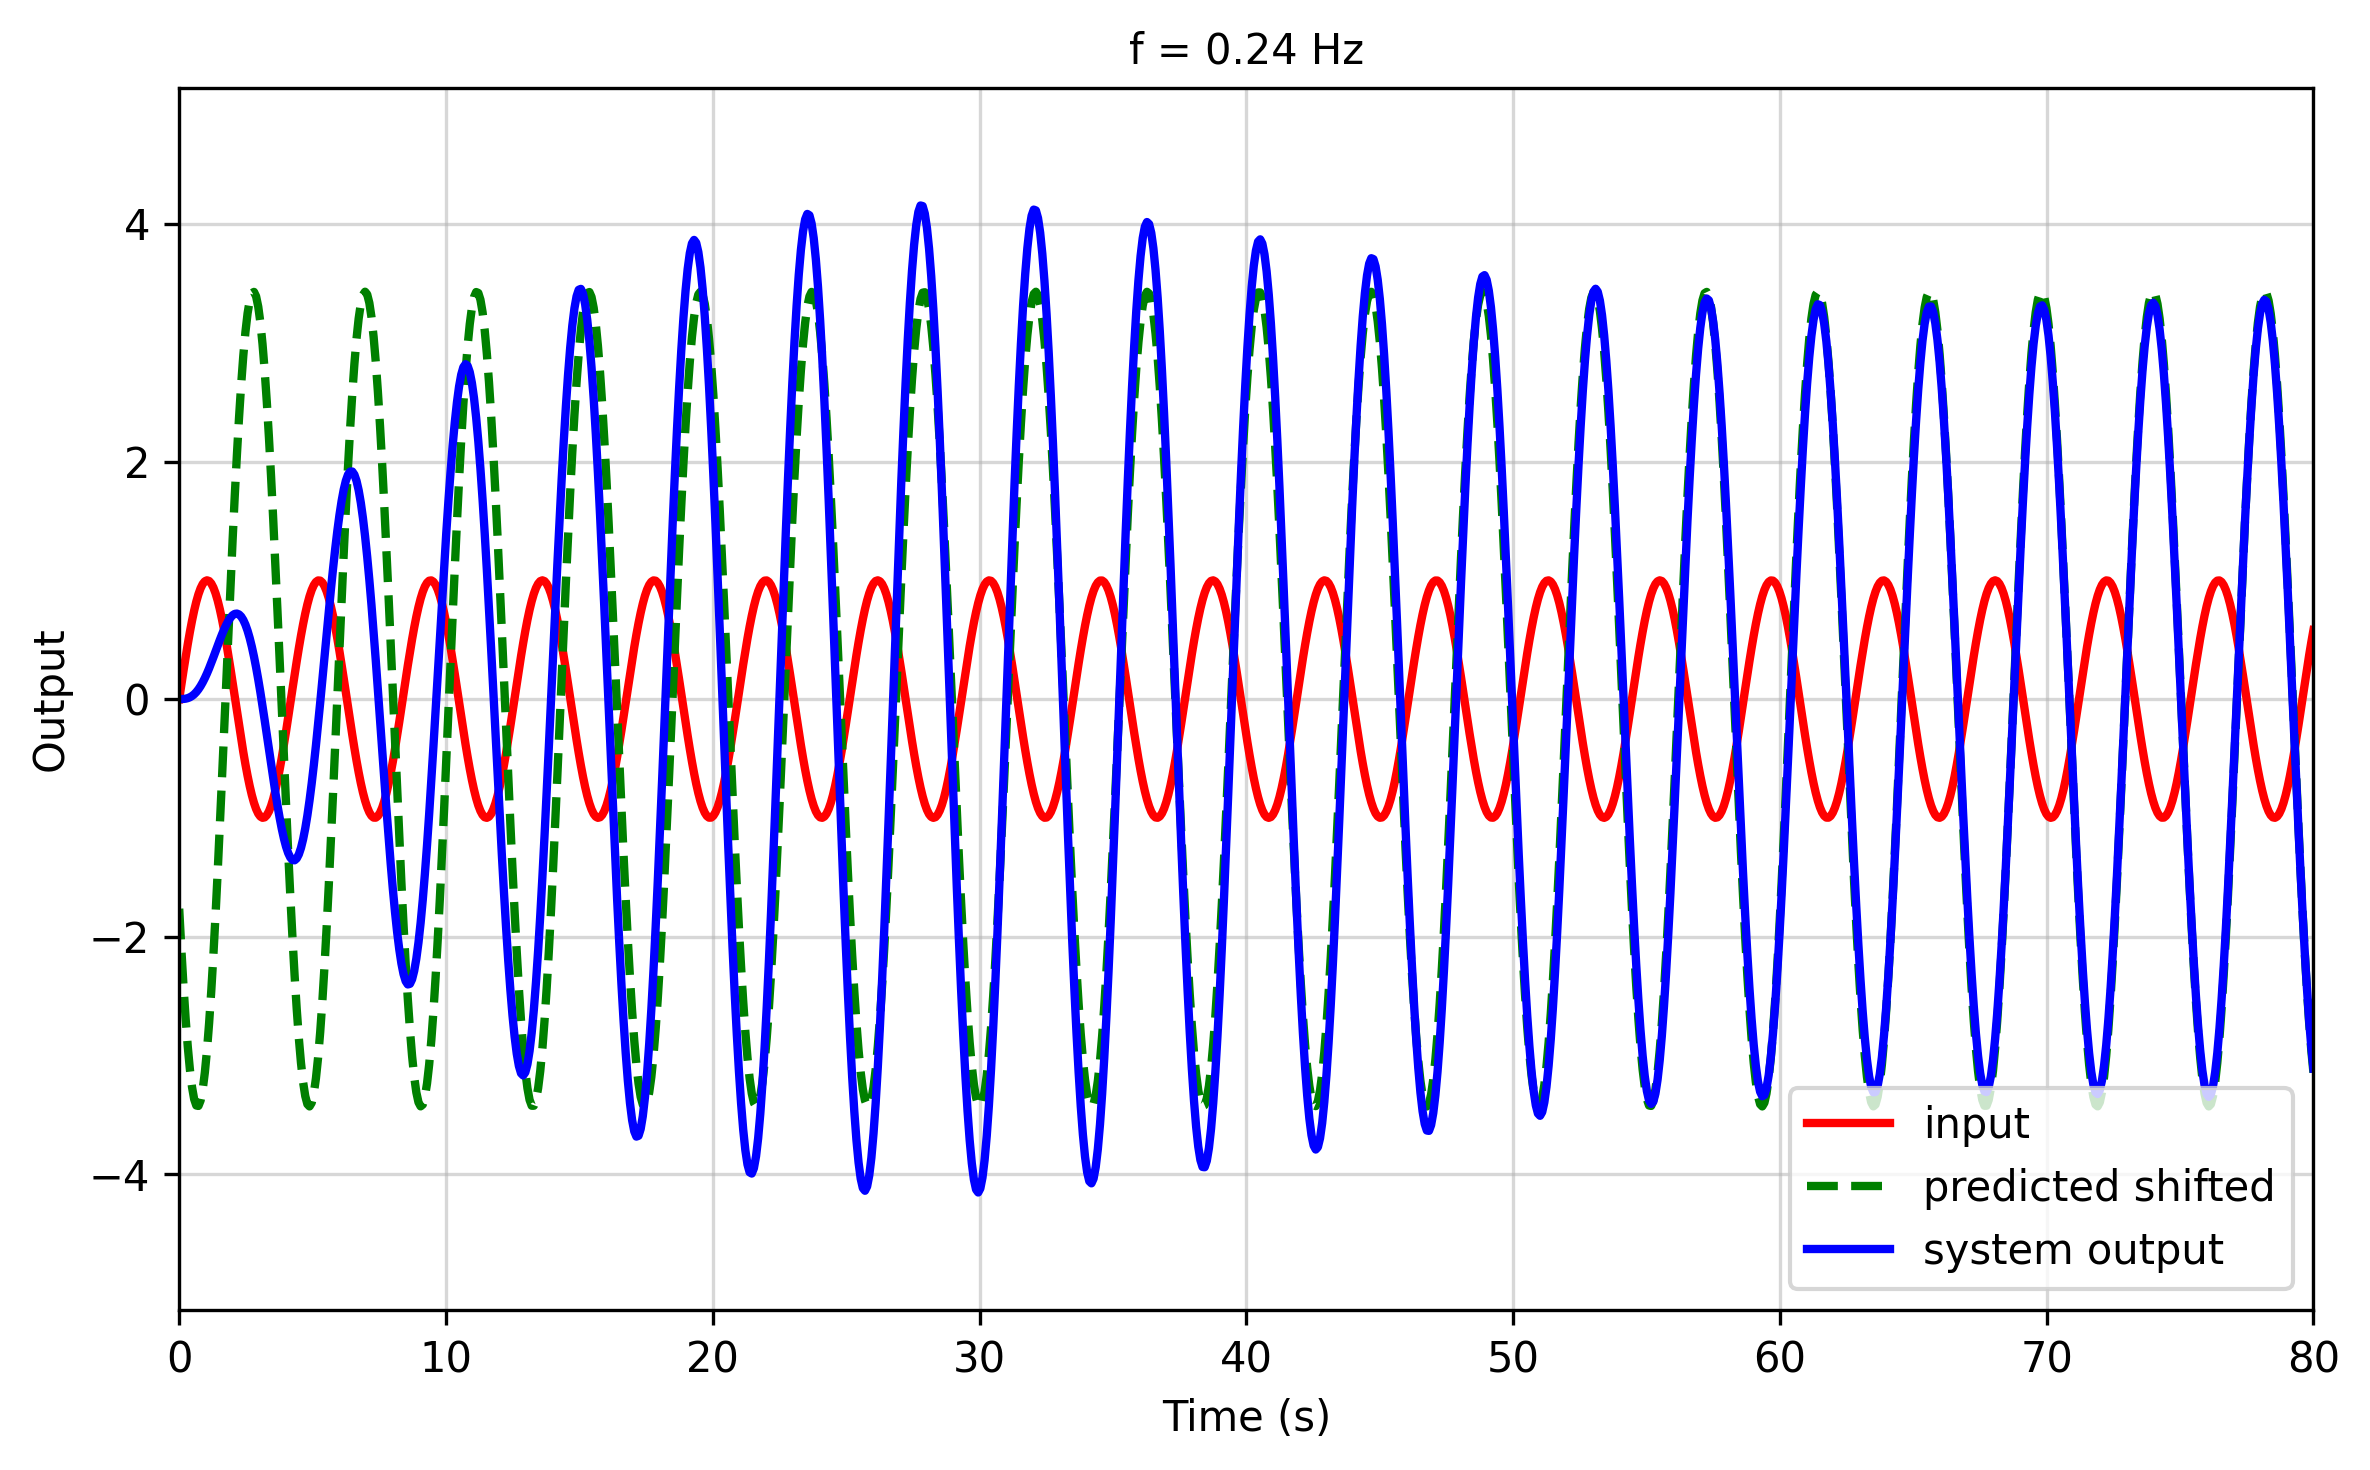

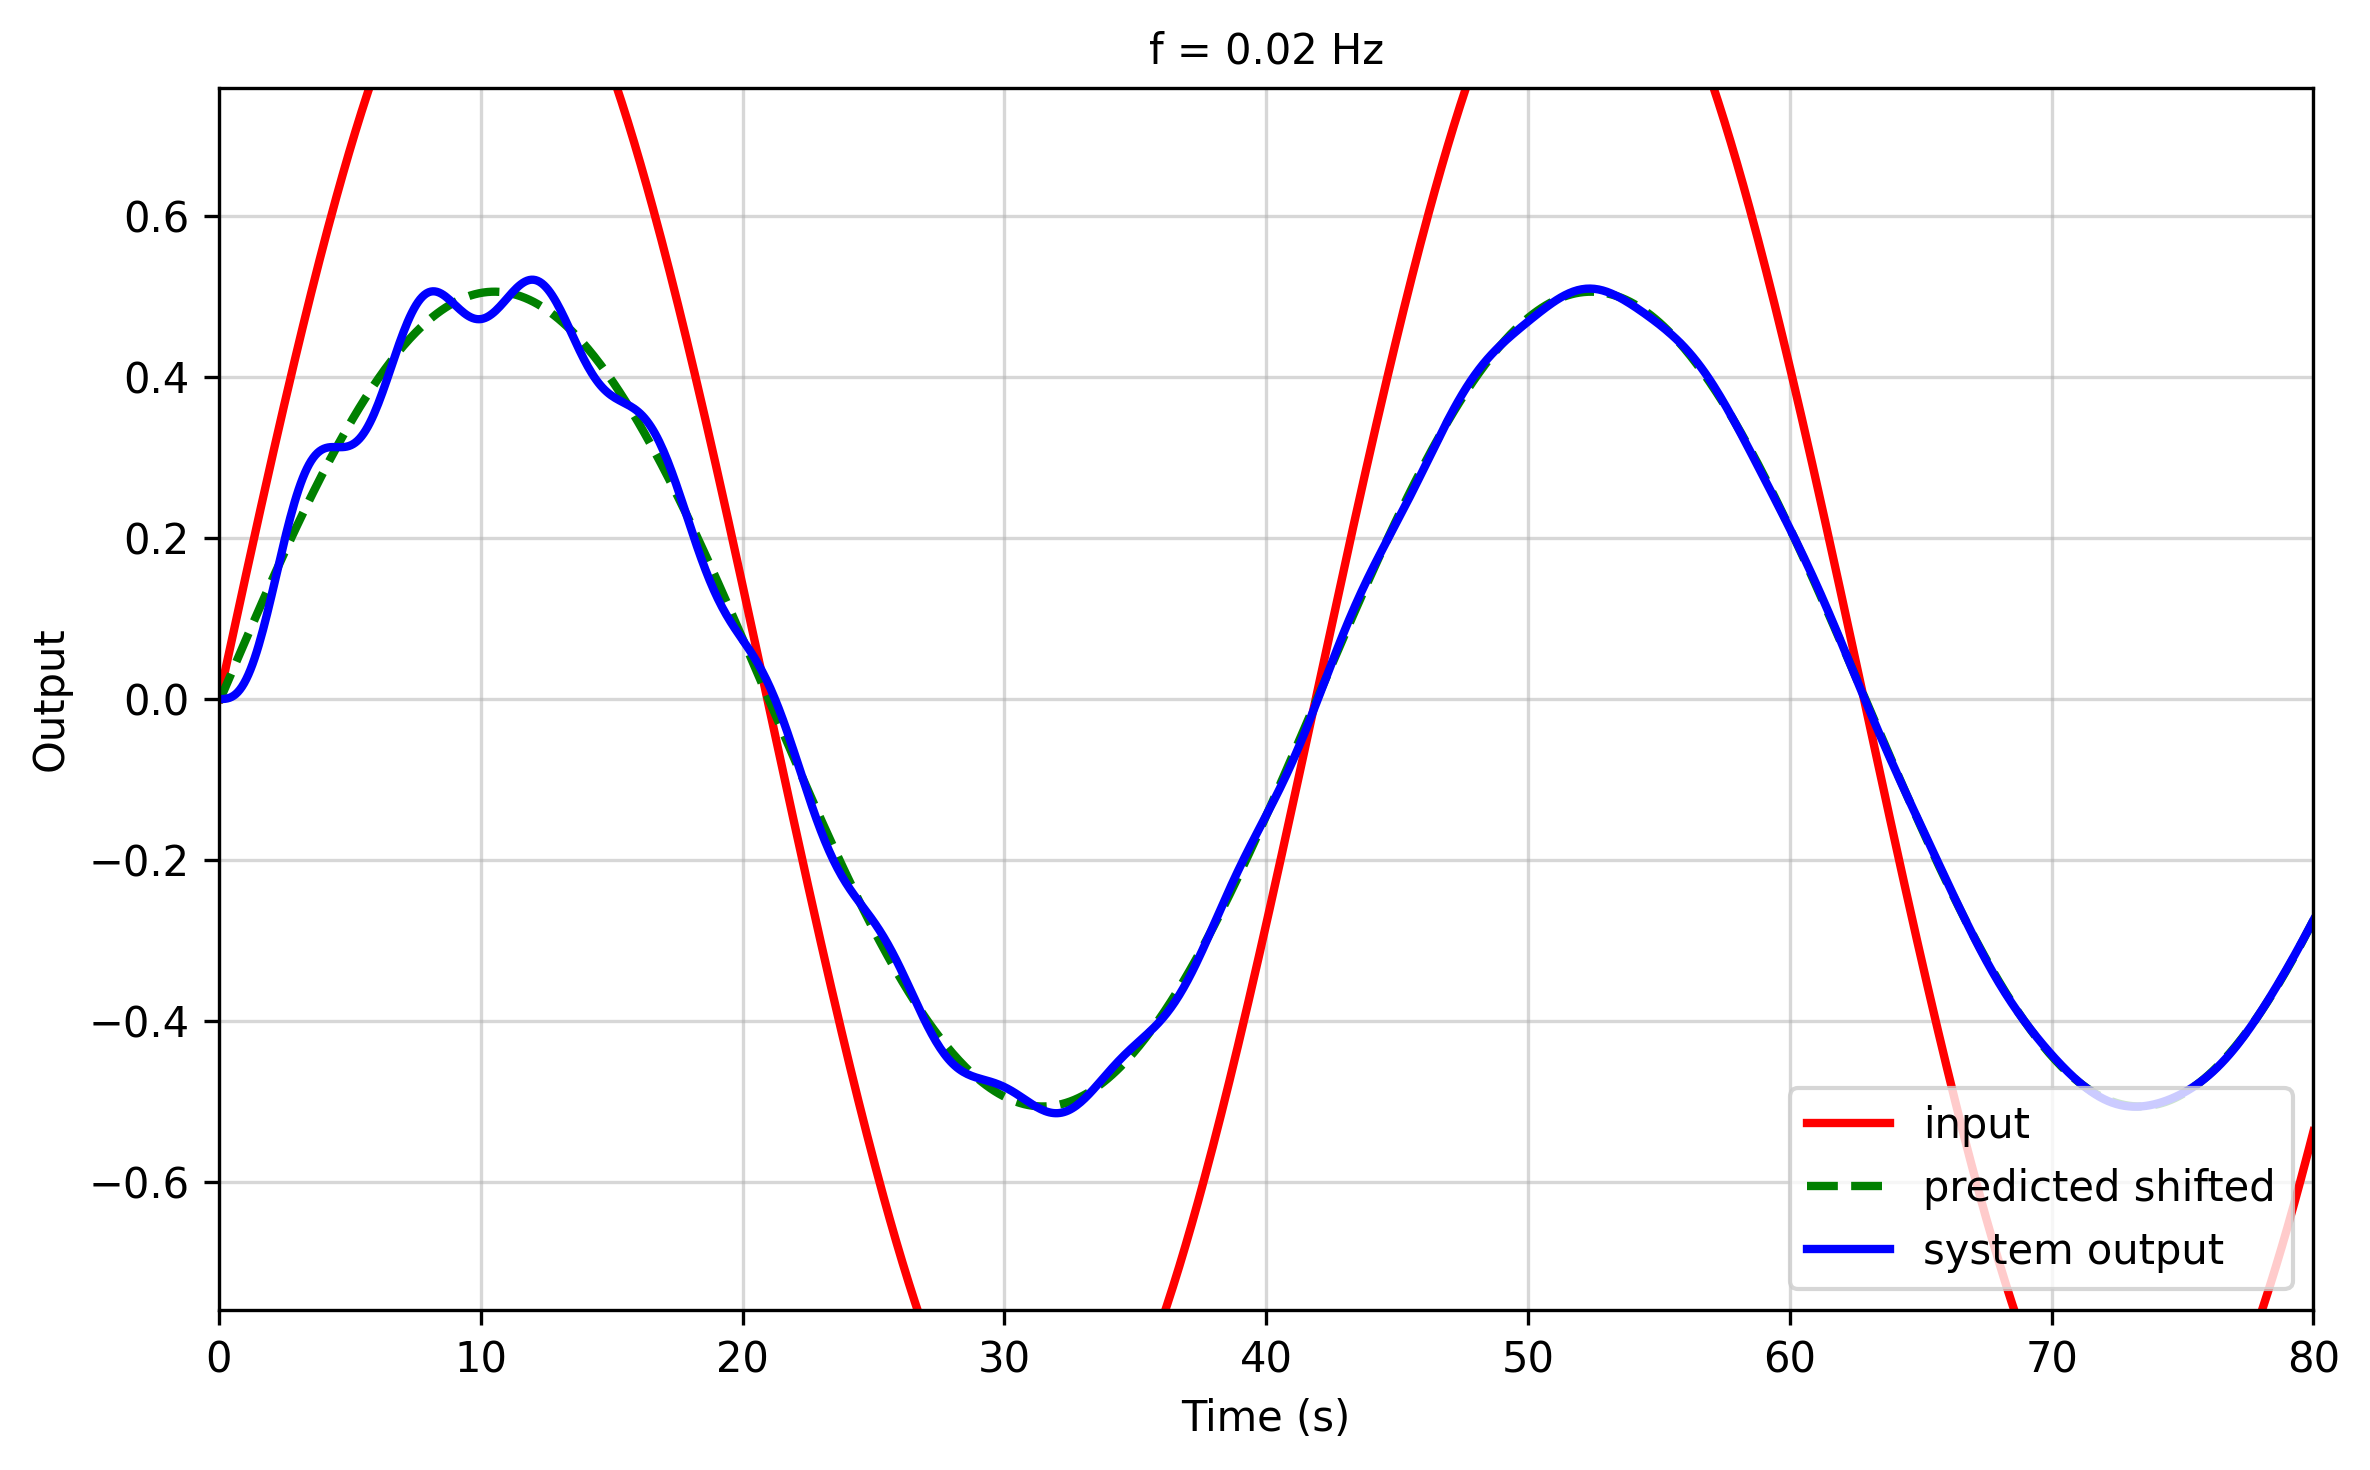

In [16]:
T = 80
for ff in [f_d, f_d/10]:
    Pf = P(1j*2*np.pi*ff)
    Pm, Pp = np.abs(Pf), np.angle(Pf)
    t = np.linspace(0, T, 1000)
    w = np.sin(2*np.pi*ff*t)
    wshift = Pm * np.sin(2*np.pi*ff*t + Pp)
    y, t, _ = cmat.lsim(P, w, t, 0)

    fig, ax = plt.subplots(1,figsize=(8,5), dpi=300, sharex = True)
    plt.plot(t, w, label='input', color='r')
    plt.plot(t, wshift, 'g--', label='predicted shifted')
    plt.plot(t, y, label='system output', color='b')

    plt.title(f"f = {ff:.2f} Hz")
    plt.legend(loc='lower right')
    plt.grid()
    plt.grid(which='minor', alpha=0.2)
    plt.grid(which='major', alpha=0.5)
    plt.xlabel('Time (s)')
    plt.ylabel('Output')
    plt.xlim(0, max(t))
    plt.ylim([-1.5*Pm, 1.5*Pm])
    fig.savefig(f'./figs/T7_s17_{ff:.2f}.pdf',  format='pdf', dpi=300)
